# Análisis de Egresos Hospitalarios — PBA 2016-2020

## Notebook 02 — Análisis profundo e insights

Acá voy más allá del EDA inicial: busco patrones, comparaciones, y respuestas a preguntas que le importarían a alguien que toma decisiones de salud pública o gestiona un hospital.

### Preguntas guía

1. ¿Cómo cambió la composición de causas entre 2016 y 2020? (efecto COVID)
2. ¿Qué municipios concentran la mayor carga asistencial?
3. ¿Cómo varía la estadía promedio según causa y grupo de edad?
4. ¿Hay diferencias significativas por sexo o grupo etario?
5. ¿Cuáles son las patologías de mayor 'costo asistencial' (volumen × estadía)?

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "app"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb

from data_loader import cargar_dataset

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)

# Cargo desde el parquet ya procesado (más rápido). 
# Si no existe, regenero desde los CSV.
parquet = ROOT / "data" / "processed" / "egresos_2016_2020.parquet"
if parquet.exists():
    df = pd.read_parquet(parquet)
    print(f"Cargado parquet: {len(df):,} filas")
else:
    df = cargar_dataset()
    print(f"Cargado desde CSV: {len(df):,} filas")

con = duckdb.connect()
con.register("egresos", df)

Cargado parquet: 790,990 filas


## 1. Composición de causas: pre vs durante pandemia

Compara las 8 causas principales entre 2019 (último año normal) y 2020 (pandemia).

In [2]:
q = """
WITH base AS (
    SELECT 
        anio,
        causa,
        SUM(cantidad_egresos) AS egresos
    FROM egresos
    WHERE anio IN (2019, 2020) AND causa IS NOT NULL
    GROUP BY anio, causa
),
top_causas AS (
    SELECT causa
    FROM base
    GROUP BY causa
    ORDER BY SUM(egresos) DESC
    LIMIT 8
)
SELECT b.anio, b.causa, b.egresos
FROM base b
JOIN top_causas t USING (causa)
ORDER BY b.causa, b.anio;
"""
comparacion = con.execute(q).df()
pivot = comparacion.pivot(index="causa", columns="anio", values="egresos").fillna(0)
pivot["cambio_pct"] = ((pivot[2020] - pivot[2019]) / pivot[2019] * 100).round(1)
pivot

anio,2019,2020,cambio_pct
causa,,,
Ciertas enfermedades infecciosas y parasitarias,38986.0,33707.0,-13.5
"Embarazo, parto y puerperio",154550.0,142402.0,-7.9
Enfermedad del sistema circulatorio,80948.0,65592.0,-19.0
Enfermedad del sistema digestivo,96289.0,74999.0,-22.1
Enfermedad del sistema genitourinario,58058.0,47170.0,-18.8
Enfermedad del sistema respiratorio,137060.0,76895.0,-43.9
"Síntomas, signos y hallazgos anormales clínicos y de laboratorio",114934.0,117875.0,2.6
"Traumatismos, envenenamientos y algunas otras consecuencias de causas externas",115982.0,99760.0,-14.0


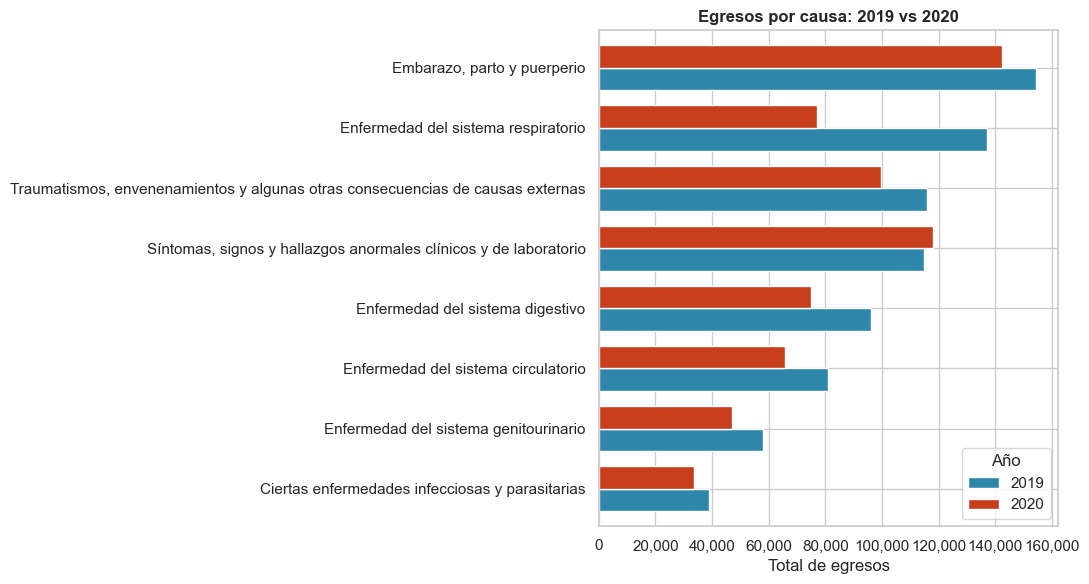

In [3]:
fig, ax = plt.subplots(figsize=(11, 6))
pivot_plot = pivot.drop(columns="cambio_pct").sort_values(2019, ascending=True)
pivot_plot.plot(kind="barh", ax=ax, color=["#2E86AB", "#C73E1D"], width=0.75)
ax.set_title("Egresos por causa: 2019 vs 2020", fontweight="bold")
ax.set_xlabel("Total de egresos")
ax.set_ylabel("")
ax.legend(title="Año")
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("../assets/05_2019vs2020.png", dpi=120, bbox_inches="tight")
plt.show()

## 2. Concentración geográfica

¿Cuántos municipios concentran el 50% de los egresos?

In [4]:
q = """
WITH muni AS (
    SELECT 
        municipio,
        SUM(cantidad_egresos) AS egresos
    FROM egresos
    WHERE municipio IS NOT NULL
    GROUP BY municipio
)
SELECT 
    municipio,
    egresos,
    ROUND(100.0 * egresos / SUM(egresos) OVER (), 2) AS pct,
    ROUND(100.0 * SUM(egresos) OVER (ORDER BY egresos DESC) / SUM(egresos) OVER (), 2) AS pct_acum
FROM muni
ORDER BY egresos DESC
LIMIT 15;
"""
concentracion = con.execute(q).df()
concentracion["municipio"] = concentracion["municipio"].astype(str)
concentracion

,municipio,egresos,pct,pct_acum
0,Malvinas Argentinas,308878.0,6.78,6.78
1,General San Martín,249984.0,5.49,12.26
2,San Isidro,222137.0,4.87,17.14
3,Merlo,215256.0,4.72,21.86
4,La Plata,207974.0,4.56,26.43
5,La Matanza,202909.0,4.45,30.88
6,Pilar,173969.0,3.82,34.70
7,Vicente López,119939.0,2.63,37.33
8,Berazategui,88127.0,1.93,39.26
9,Tigre,86888.0,1.91,41.17


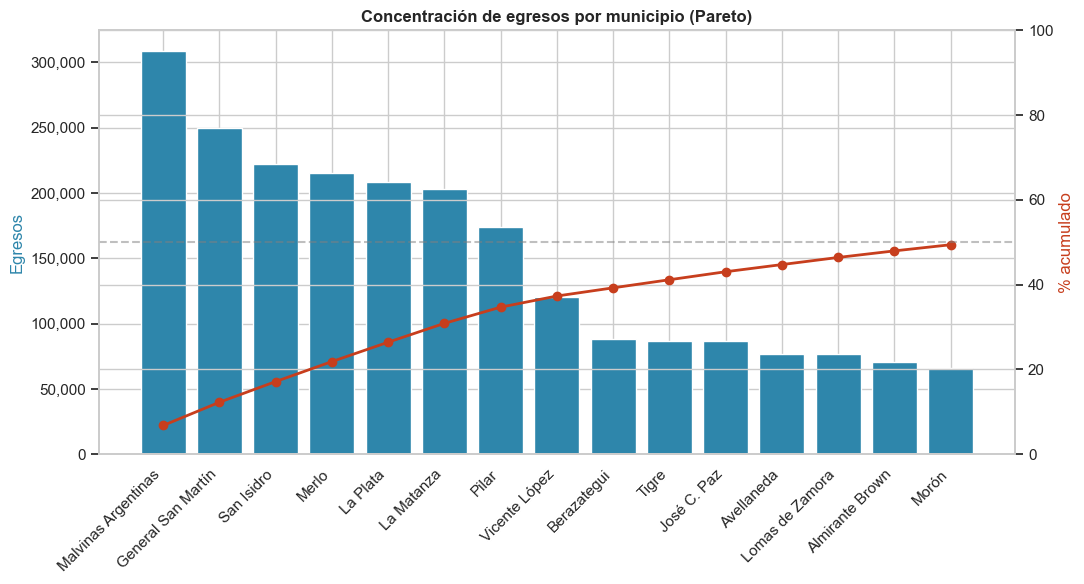

In [5]:
fig, ax1 = plt.subplots(figsize=(11, 6))
data = concentracion.head(15)
ax1.bar(data["municipio"], data["egresos"], color="#2E86AB")
ax1.set_xlabel("")
ax1.set_ylabel("Egresos", color="#2E86AB")
ax1.tick_params(axis="x", rotation=45)
ax1.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for label in ax1.get_xticklabels():
    label.set_ha("right")

ax2 = ax1.twinx()
ax2.plot(data["municipio"], data["pct_acum"], color="#C73E1D",
         marker="o", linewidth=2)
ax2.axhline(50, color="gray", linestyle="--", alpha=0.5)
ax2.set_ylabel("% acumulado", color="#C73E1D")
ax2.set_ylim(0, 100)

plt.title("Concentración de egresos por municipio (Pareto)", fontweight="bold")
plt.tight_layout()
plt.savefig("../assets/06_pareto_municipios.png", dpi=120, bbox_inches="tight")
plt.show()

## 3. Días de estadía: heatmap por causa y año

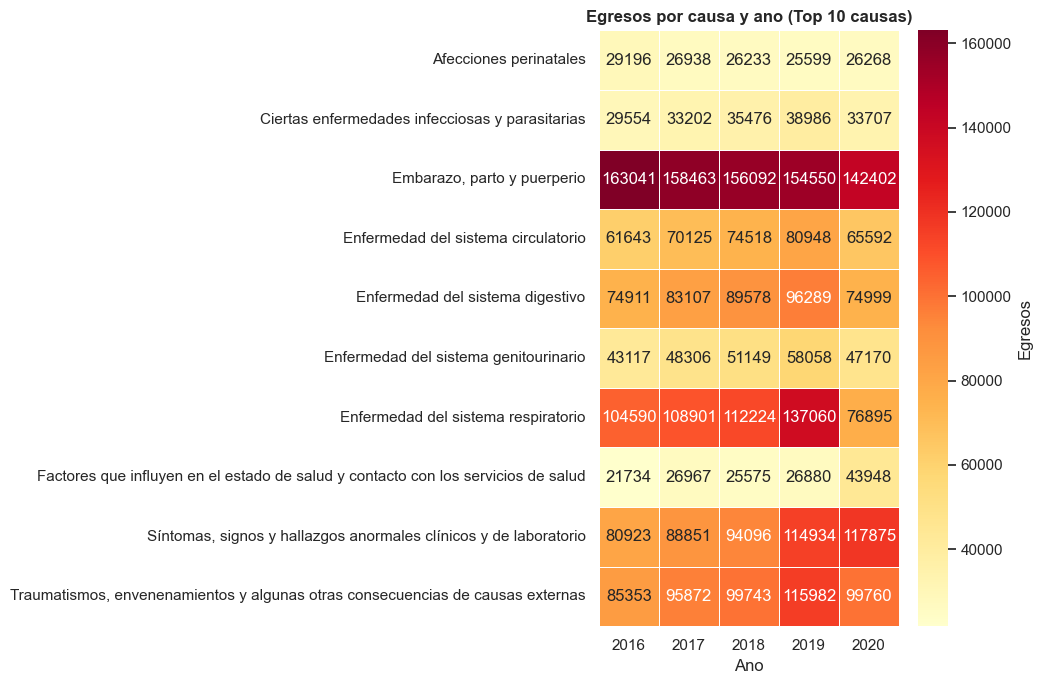

In [6]:
q = """
WITH top_causas AS (
    SELECT causa
    FROM egresos
    WHERE causa IS NOT NULL
    GROUP BY causa
    ORDER BY SUM(cantidad_egresos) DESC
    LIMIT 10
)
SELECT 
    e.causa,
    e.anio,
    SUM(e.cantidad_egresos) AS egresos
FROM egresos e
JOIN top_causas t USING (causa)
WHERE e.causa IS NOT NULL
GROUP BY e.causa, e.anio
ORDER BY e.causa, e.anio;
"""
heatmap_data = con.execute(q).df().pivot(index="causa", columns="anio", values="egresos")
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"label": "Egresos"}, ax=ax)
ax.set_title("Egresos por causa y ano (Top 10 causas)", fontweight="bold")
ax.set_xlabel("Ano")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../assets/07_heatmap_egresos.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Análisis demográfico

Si el dataset tiene `sexo` y `grupo_edad`, los explotamos. Si no, esta sección se salta.

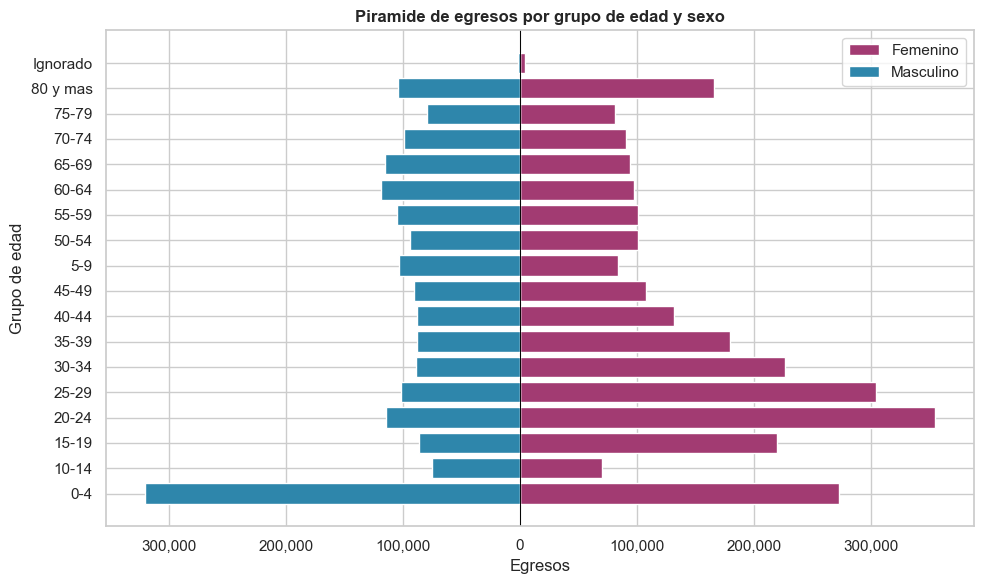

In [7]:
tiene_demograficos = "sexo" in df.columns and "grupo_edad" in df.columns

if tiene_demograficos:
    q = """
    SELECT
        grupo_edad,
        sexo,
        SUM(cantidad_egresos) AS egresos
    FROM egresos
    WHERE grupo_edad IS NOT NULL AND sexo IS NOT NULL
    GROUP BY grupo_edad, sexo
    ORDER BY grupo_edad, sexo;
    """
    demo = con.execute(q).df()

    pivot_demo = demo.pivot(index="grupo_edad", columns="sexo", values="egresos").fillna(0)
    if "Masculino" in pivot_demo.columns:
        pivot_demo["Masculino"] = -pivot_demo["Masculino"]

    fig, ax = plt.subplots(figsize=(10, 6))
    if "Femenino" in pivot_demo.columns:
        ax.barh(pivot_demo.index, pivot_demo["Femenino"], color="#A23B72", label="Femenino")
    if "Masculino" in pivot_demo.columns:
        ax.barh(pivot_demo.index, pivot_demo["Masculino"], color="#2E86AB", label="Masculino")
    ax.axvline(0, color="black", linewidth=0.7)
    ax.set_title("Piramide de egresos por grupo de edad y sexo", fontweight="bold")
    ax.set_xlabel("Egresos")
    ax.set_ylabel("Grupo de edad")
    ax.legend()
    ax.xaxis.set_major_formatter(
        plt.matplotlib.ticker.FuncFormatter(lambda x, _: f"{abs(int(x)):,}")
    )
    plt.tight_layout()
    plt.savefig("../assets/08_piramide.png", dpi=120, bbox_inches="tight")
    plt.show()
else:
    print("El dataset no tiene columnas sexo / grupo_edad. Seccion omitida.")


## 5. 'Carga asistencial': causas que más capacidad consumen

Defino **carga asistencial** = egresos × días de estadía promedio.
Esto aproxima cuántos días-cama consume cada patología.

In [8]:
# La columna dias_estadia_promedio no existe en el dataset real.
# Se muestra el top causas por volumen de egresos.
q = """
SELECT 
    causa,
    SUM(cantidad_egresos) AS volumen
FROM egresos
WHERE causa IS NOT NULL
GROUP BY causa
ORDER BY volumen DESC
LIMIT 10;
"""
carga = con.execute(q).df()
carga

,causa,volumen
0,"Embarazo, parto y puerperio",774548.0
1,Enfermedad del sistema respiratorio,539670.0
2,"Traumatismos, envenenamientos y algunas otras ...",496710.0
3,"Síntomas, signos y hallazgos anormales clínico...",496679.0
4,Enfermedad del sistema digestivo,418884.0
5,Enfermedad del sistema circulatorio,352826.0
6,Enfermedad del sistema genitourinario,247800.0
7,Ciertas enfermedades infecciosas y parasitarias,170925.0
8,Factores que influyen en el estado de salud y ...,145104.0
9,Afecciones perinatales,134234.0


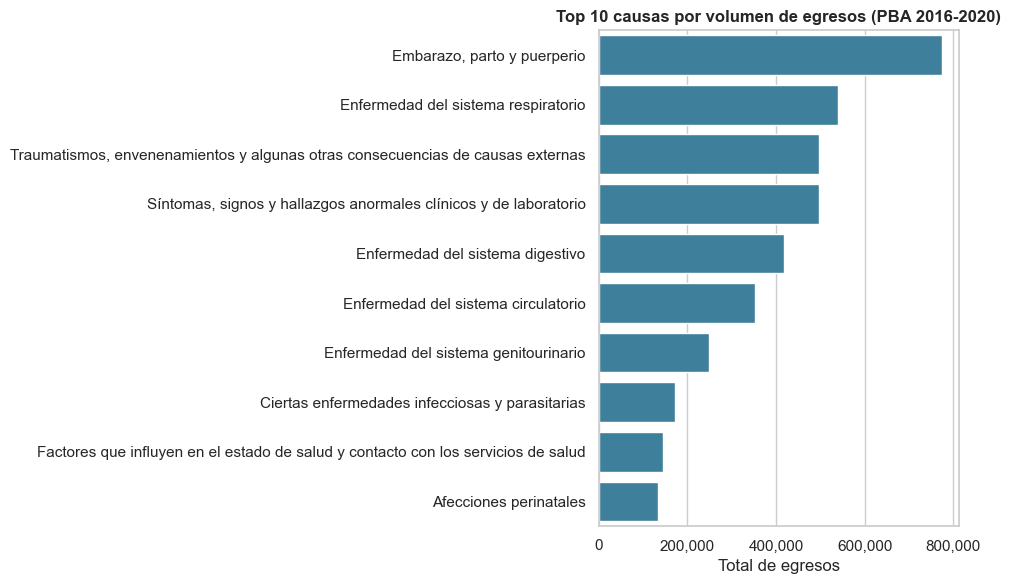

In [9]:
# Visualizacion adaptada: barplot de top causas por volumen (sin dias_estadia_promedio)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=carga, y="causa", x="volumen", color="#2E86AB", ax=ax)
ax.set_title("Top 10 causas por volumen de egresos (PBA 2016-2020)", fontweight="bold")
ax.set_xlabel("Total de egresos")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("../assets/08_top_causas_volumen.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Conclusiones e insights

_Completá con tus hallazgos al correr el notebook:_

1. **Efecto pandemia (2020):** _qué causas crecieron y cuáles cayeron_.
2. **Concentración territorial:** _cuántos municipios concentran el 50% / 80% de los egresos_.
3. **Patologías de alta estadía:** _cuáles consumen más días-cama por egreso_.
4. **Demografía:** _en qué grupos de edad / sexo se concentran qué causas_.
5. **Implicancias para gestión:** _dónde apuntar recursos / prevención_.

### Próximos pasos

- Cruzar con datos socioeconómicos por municipio.
- Hacer un modelo predictivo de estadía por causa + demografía.
- Dashboard interactivo: ver `app/app.py`.